In [ ]:
from sheet_1 import simulate
from qiskit import QuantumCircuit
import numpy as np




# Gates

Qiskit can transpile all gates to a series of basis gates, in our case the one qubit rotation gate 'u' and the two qubit gate 'cx'. These two gates were defined in 'apply_u_on_state.py' and 'apply_cx_on_state.py'. 

## u gate

In [ ]:
import numpy as np

def apply_u_on_state(state: np.ndarray, u: np.ndarray, acting_on: int) -> np.ndarray:
    """Applies a single-qubit gate to the given state vector. The gate is defined 
    by the 2x2 matrix u, and it acts on the qubit specified by acting_on"""
    number_of_qubits=state.ndim
    acting_on=number_of_qubits-acting_on-1
    old_indices = [i for i in range(number_of_qubits)]
    new_indices = old_indices.copy()
    new_indices[acting_on] = 51
    result=np.einsum(u,[51,acting_on],state,old_indices,new_indices)
    return result

## cx gate

In [ ]:
import numpy as np

def apply_cx_on_state(state: np.ndarray, cx: np.ndarray, acting_on1: int, acting_on2: int) -> np.ndarray:
    '''Applies a CNOT gate to the given state vector. The CNOT gate is defined 
    by the 4x4 matrix cx, and it acts on the qubits specified by acting_on1 (control) 
    and acting_on2 (target). The state vector is modified in-place.'''
    number_of_qubits=state.ndim
    acting_on1=number_of_qubits-1-acting_on1
    acting_on2=number_of_qubits-1-acting_on2
    cx_matrix=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])
    cx = np.reshape(cx_matrix,(2,2,2,2))
    old_indices = [i for i in range(number_of_qubits)]
    new_indices = old_indices.copy()
    new_indices[acting_on1] = 51
    new_indices[acting_on2] = 50
    result=np.einsum(cx,[51,50,acting_on1,acting_on2],state,old_indices,new_indices)
    return result

# Simulator using np.einsum

The simulator uses the two gates 'u' and 'cx'. It simulates the, to basisgates 'u' and 'cx' transpiled, quantum circuit and returns the final state vector.

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate, UGate, CXGate
from qiskit_aer import AerSimulator
from sheet_1.apply_cx_on_state import apply_cx_on_state
from sheet_1.apply_u_on_state import apply_u_on_state
import numpy as np
from qiskit.quantum_info import Statevector



def simulate(qc: QuantumCircuit, parameters: dict | None = None) -> np.ndarray:
    """Simulates the given quantum circuit and returns the final state vector."""
    number_of_qubits=qc.num_qubits
    psi=np.zeros(2**number_of_qubits)
    psi[0]=1
    psi_converted = np.reshape(psi,[2]*number_of_qubits)

    for instr, qargs, cargs in qc.data:
        qubit_indices = [qc.find_bit(q).index for q in qargs]

        if instr.name == 'cx':
            cx=np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])
            psi_converted=apply_cx_on_state(psi_converted,cx,qubit_indices[0], qubit_indices[1])
        elif instr.name == 'u':
            u=UGate(instr.params[0],instr.params[1],instr.params[2]).to_matrix()
            psi_converted=apply_u_on_state(psi_converted,u,qubit_indices[0])
        else:
            continue
    
    psi_final = np.reshape(np.asarray(psi_converted), (2**number_of_qubits,))
    return psi_final












The simulator was tested with a simple and a random circuit. 

# Benchmarks

The runtime of our own simulator and the Aer_simulator were compared. To do this two functions constructing circuits and parameters for both simulators were defined. Then benchmarked testfunctions were defined. In a last step the two statevectors were compared, to ensure correctness of the simulator. This test is not benchmarked.  

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.circuit.random import random_circuit
from sheet_1 import quantum_simulator
from qiskit_aer import AerSimulator

import numpy as np
import pytest


# ----------------------------
# Circuit construction helpers
# ----------------------------

def construct_simple_circuit():
    number_of_qubits = 3
    qc = QuantumCircuit(number_of_qubits)
    qc.h(0)
    qc.h(1)
    qc.h(2)
    return qc


def construct_random_circuit():
    # fixed seed for reproducibility
    return random_circuit(num_qubits=12, depth=10, measure=False, seed=42)


# ----------------------------
# Shared parametrization
# ----------------------------

@pytest.fixture(params=[construct_simple_circuit, construct_random_circuit])
def circuit(request):
    qc = request.param()
    qc = transpile(qc, basis_gates=['u', 'cx'])
    return qc


# ----------------------------
# Benchmarks
# ----------------------------

def test_aer_simulation(benchmark, circuit):
    """Benchmark Qiskit Aer statevector simulation"""
    circuit.save_statevector()
    simulator = AerSimulator(method="statevector")
    compiled = transpile(circuit, simulator)

    def run():
        result = simulator.run(compiled).result()
        return result.get_statevector()

    result = benchmark(run)

    # basic sanity check (not strict comparison here)
    assert result is not None



def test_own_simulation(benchmark, circuit):
    """Benchmark your custom simulator"""
    def run():
        return quantum_simulator.simulate(circuit, None)

    result = benchmark(run)

    assert result is not None


# ----------------------------
# Correctness test (no benchmark)
# ----------------------------

@pytest.mark.parametrize("construction_function", [construct_simple_circuit, construct_random_circuit])
def test_correctness(construction_function):
    qc = construction_function()
    qc = transpile(qc, basis_gates=['u', 'cx'])

    aer_state = Statevector.from_instruction(qc)
    own_state = quantum_simulator.simulate(qc, None)

    # compare states up to global phase
    idx = np.argmax(np.abs(aer_state))
    global_phase = aer_state.data[idx] / own_state[idx]

    assert np.allclose(aer_state, own_state * global_phase)

# Gates using numba

The code for the gates was modified using numba to substitude 'np.einsum' with for-loops.



## 'u' gate

In [ ]:
import numba 
import numpy as np

@numba.jit(cache=True)
def apply_u_numba(state: np.ndarray, u: np.ndarray, acting_on: int) -> np.ndarray:
    number_of_qubits=int(np.log2(state.size))
    #acting_on=number_of_qubits-acting_on-1
    for idx_lower in range(0, 2**acting_on):
        for idx_upper in range(0, 2**number_of_qubits, 2**(acting_on+1)):
            idx0 = idx_lower + idx_upper
            idx1 = idx_upper + idx_lower + 2**acting_on
            s0 = state[idx0]
            s1 = state[idx1]
            state[idx0] = u[0, 0] * s0 + u[0, 1] * s1
            state[idx1] = u[1, 0] * s0 + u[1, 1] * s1
    return state

## 'cx' Gate

In [ ]:
import numba
import numpy as np

@numba.njit(cache=True)
def apply_cx_numba(state: np.ndarray, control: int, target: int) -> np.ndarray:
    if control == target:
        return state.copy()

    result = state.copy()
    number_of_qubits = int(np.log2(state.size))

    lower_qubit = control if control < target else target
    higher_qubit = target if control < target else control

    lower_stride = 1 << lower_qubit
    higher_stride = 1 << higher_qubit

    for idx_lower in range(0, lower_stride):
        for idx_middle in range(0, higher_stride, 1 << (lower_qubit + 1)):
            for idx_higher in range(0, 1 << number_of_qubits, 1 << (higher_qubit + 1)):
                base = idx_higher + idx_middle + idx_lower
                idx_01 = base + lower_stride
                idx_10 = base + higher_stride
                idx_11 = idx_10 + lower_stride

                if control > target:
                    tmp = result[idx_10]
                    result[idx_10] = result[idx_11]
                    result[idx_11] = tmp
                else:
                    tmp = result[idx_01]
                    result[idx_01] = result[idx_11]
                    result[idx_11] = tmp

    return result


## Test for numba gates

The gates with numba were tested against the AerSimulator. 


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate, UGate, CXGate
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import numpy as np
from qiskit.circuit.random import random_circuit
from sheet_1.apply_u_numba import apply_u_numba

theta = np.pi/3
phi=np.pi/8
lam=0
apply_to=4
number_of_qubits=9

qc = random_circuit(num_qubits=number_of_qubits, depth=10, measure=False, seed=42)
tqc = transpile(qc, basis_gates=['u', 'cx'])
initial_state = Statevector.from_instruction(tqc)

# simulate result using AerSimulator
qc2 = QuantumCircuit(number_of_qubits)
qc2.u(theta,phi,lam,apply_to)
Aer_result = initial_state.evolve(qc2)

# set up u gate
u=UGate(theta,phi,lam).to_matrix()

result = apply_u_numba(initial_state.data, u, apply_to)


global_phase=1

assert np.allclose(Aer_result.data, result*global_phase, atol=1e-12)


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
import numpy as np
from qiskit.circuit.random import random_circuit
from sheet_1.apply_cx_numba import apply_cx_numba

def test_apply_cx_numba_matches_qiskit_evolution():
	control = 0
	target = 1
	number_of_qubits = 9

	qc = random_circuit(num_qubits=number_of_qubits, depth=10, measure=False, seed=42)
	tqc = transpile(qc, basis_gates=["u", "cx"])
	initial_state = Statevector.from_instruction(tqc)

	qc2 = QuantumCircuit(number_of_qubits)
	qc2.cx(control, target)
	aer_result = initial_state.evolve(qc2)

	result = apply_cx_numba(initial_state.data, control, target)

	assert np.allclose(aer_result.data, result, atol=1e-12)


## Simulator with numba

The quantum simulator was adjusted to use the gates defined with numba. The functions are apply_u_numba and apply_cx_numba.

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import UGate
from sheet_1.apply_cx_numba import apply_cx_numba
from sheet_1.apply_u_numba import apply_u_numba
import numpy as np


def simulate_numba(qc: QuantumCircuit, parameters: dict | None = None) -> np.ndarray:
    """Simulates the given quantum circuit and returns the final state vector."""
    number_of_qubits = qc.num_qubits
    psi = np.zeros(2**number_of_qubits, dtype=np.complex128)
    psi[0] = 1.0 + 0.0j

    for circuit_instruction in qc.data:
        instr = circuit_instruction.operation
        qargs = circuit_instruction.qubits
        qubit_indices = [qc.find_bit(q).index for q in qargs]

        if instr.name == 'cx':
            psi = apply_cx_numba(psi, qubit_indices[0], qubit_indices[1])
        elif instr.name == 'u':
            u = UGate(instr.params[0], instr.params[1], instr.params[2]).to_matrix()
            psi = apply_u_numba(psi, np.asarray(u), qubit_indices[0])
        else:
            continue
    
    return psi

            









## Benchmark numba

The simulator using numba was bechmarked against the AerSimulator and the one using np.einsum. 

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.circuit.random import random_circuit
from sheet_1 import simulator_numba
from sheet_1 import quantum_simulator
from qiskit_aer import AerSimulator

import numba
import numpy as np
import pytest


# ----------------------------
# Circuit construction helpers
# ----------------------------

def construct_simple_circuit():
    number_of_qubits = 3
    qc = QuantumCircuit(number_of_qubits)
    qc.h(0)
    qc.h(1)
    qc.h(2)
    return qc


def construct_random_circuit():
    # fixed seed for reproducibility
    return random_circuit(num_qubits=12, depth=10, measure=False, seed=42)


# ----------------------------
# Shared parametrization
# ----------------------------

@pytest.fixture(params=[construct_simple_circuit, construct_random_circuit])
def circuit(request):
    qc = request.param()
    qc = transpile(qc, basis_gates=['u', 'cx'])
    return qc


# ----------------------------
# Benchmarks
# ----------------------------

# sollte gleich bleiben, oder?

def test_aer_simulation(benchmark, circuit):
    """Benchmark Qiskit Aer statevector simulation"""
    circuit.save_statevector()
    simulator = AerSimulator(method="statevector")
    compiled = transpile(circuit, simulator)

    def run():
        result = simulator.run(compiled).result()
        return result.get_statevector()

    result = benchmark(run)

    # basic sanity check (not strict comparison here)
    assert result is not None



@numba.njit(cache=True)
def test_numba_simulation(benchmark, circuit):
    """Benchmark your custom simulator"""
    def run():
        return simulator_numba.simulate_numba(circuit, None)

    result = benchmark(run)

    assert result is not None


def test_einsum_simulation(benchmark, circuit):
    """Benchmark your custom simulator"""
    def run():
        return quantum_simulator.simulate(circuit, None)

    result = benchmark(run)

    assert result is not None


# ----------------------------
# Correctness test (no benchmark)
# ----------------------------

@pytest.mark.parametrize("construction_function", [construct_simple_circuit, construct_random_circuit])
def test_correctness(construction_function):
    qc = construction_function()
    qc = transpile(qc, basis_gates=['u', 'cx'])

    aer_state = Statevector.from_instruction(qc)
    numba_state = simulator_numba.simulate_numba(qc, None)

    # compare states up to global phase
    idx = np.argmax(np.abs(aer_state))
    global_phase = aer_state.data[idx] / numba_state[idx]

    assert np.allclose(aer_state, numba_state * global_phase)

### Runtime Plot

This benchmark compares Aer, numba, and einsum simulators on the same transpiled random circuits and plots the runtimes.

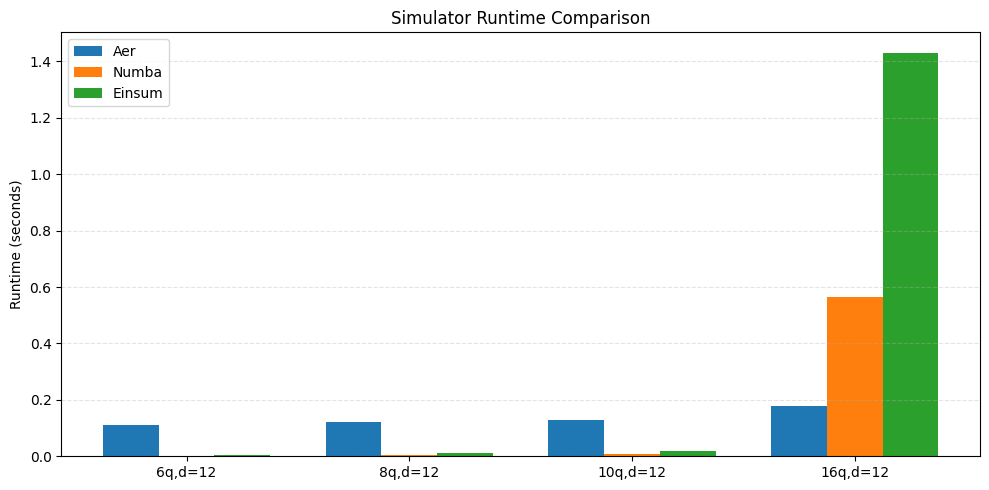

Average runtime per case (seconds):
   6q,d=12 | Aer: 0.111721 | Numba: 0.002257 | Einsum: 0.004235
   8q,d=12 | Aer: 0.121596 | Numba: 0.003691 | Einsum: 0.011226
  10q,d=12 | Aer: 0.126942 | Numba: 0.006976 | Einsum: 0.020248
  16q,d=12 | Aer: 0.177079 | Numba: 0.566431 | Einsum: 1.431467


In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit.circuit.random import random_circuit
from qiskit_aer import AerSimulator
from sheet_1 import quantum_simulator, simulator_numba


def build_circuit(num_qubits: int, depth: int, seed: int):
    qc = random_circuit(num_qubits=num_qubits, depth=depth, measure=False, seed=seed)
    return transpile(qc, basis_gates=['u', 'cx'])


def run_aer(circuit, simulator):
    circuit_for_aer = circuit.copy()
    circuit_for_aer.save_statevector()
    compiled = transpile(circuit_for_aer, simulator)
    result = simulator.run(compiled).result()
    return result.get_statevector()


def average_runtime(func, repeat=3):
    timings = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        func()
        t1 = time.perf_counter()
        timings.append(t1 - t0)
    return float(np.mean(timings))


simulator = AerSimulator(method='statevector')
# Keep this moderate so the notebook remains responsive.
cases = [
    {'qubits': 6, 'depth': 12, 'seed': 33},
    {'qubits': 8, 'depth': 12, 'seed': 33},
    {'qubits': 10, 'depth': 12, 'seed': 33},
    {'qubits': 16, 'depth': 12, 'seed': 33},
    #{'qubits': 24, 'depth': 22, 'seed': 33},
]

labels = []
aer_times = []
numba_times = []
einsum_times = []

for case in cases:
    qc = build_circuit(case['qubits'], case['depth'], case['seed'])

    # Warm up numba compilation once per circuit shape.
    _ = simulator_numba.simulate_numba(qc, None)

    labels.append(f"{case['qubits']}q,d={case['depth']}")
    aer_times.append(average_runtime(lambda: run_aer(qc, simulator), repeat=3))
    numba_times.append(average_runtime(lambda: simulator_numba.simulate_numba(qc, None), repeat=3))
    einsum_times.append(average_runtime(lambda: quantum_simulator.simulate(qc, None), repeat=3))

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, aer_times, width=width, label='Aer')
plt.bar(x, numba_times, width=width, label='Numba')
plt.bar(x + width, einsum_times, width=width, label='Einsum')

plt.xticks(x, labels)
plt.ylabel('Runtime (seconds)')
plt.title('Simulator Runtime Comparison')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

print('Average runtime per case (seconds):')
for i, label in enumerate(labels):
    print(
        f"{label:>10} | Aer: {aer_times[i]:.6f} | Numba: {numba_times[i]:.6f} | Einsum: {einsum_times[i]:.6f}"
    )

# Cuda 

## Gates

The u and cx gate were done with cuda.

In [ ]:
import numpy as np
from numba import cuda


@cuda.jit
def _apply_u_kernel(state, u, acting_on, number_of_qubits, size):
    pair_id = cuda.grid(1)
    half_size = size >> 1
    if pair_id >= half_size:
        return

    idx0 = 0
    src = pair_id

    # Reconstruct basis index from pair_id while fixing acting_on bit to 0.
    for bit_pos in range(number_of_qubits):
        if bit_pos == acting_on:
            continue
        bit_val = src & 1
        src >>= 1
        idx0 |= bit_val << bit_pos

    idx1 = idx0 + (1 << acting_on)

    s0 = state[idx0]
    s1 = state[idx1]

    state[idx0] = u[0, 0] * s0 + u[0, 1] * s1
    state[idx1] = u[1, 0] * s0 + u[1, 1] * s1


def apply_u_cuda(state: np.ndarray, u: np.ndarray, acting_on: int, threads_per_block: int = 256) -> np.ndarray:
    """Apply a single-qubit U gate to a statevector on the GPU using Numba CUDA.

    Args:
        state: Statevector with shape (2**n,) and complex dtype.
        u: 2x2 unitary matrix.
        acting_on: Qubit index in little-endian convention.
        threads_per_block: CUDA threads per block.

    Returns:
        Updated statevector copied back to host memory.
    """
    if not cuda.is_available():
        raise RuntimeError("CUDA is not available. Install CUDA toolkit/driver and use a CUDA-enabled GPU.")

    if state.ndim != 1:
        raise ValueError("state must be a 1D array with shape (2**n,)")
    if u.shape != (2, 2):
        raise ValueError("u must have shape (2, 2)")

    size = state.size
    if size == 0 or (size & (size - 1)) != 0:
        raise ValueError("state length must be a non-zero power of two")

    number_of_qubits = int(np.log2(size))
    if acting_on < 0 or acting_on >= number_of_qubits:
        raise ValueError("acting_on is out of range for the given statevector")

    host_state = np.asarray(state, dtype=np.complex128).copy()
    host_u = np.asarray(u, dtype=np.complex128)

    d_state = cuda.to_device(host_state)
    d_u = cuda.to_device(host_u)

    half_size = size >> 1
    blocks_per_grid = (half_size + threads_per_block - 1) // threads_per_block
    _apply_u_kernel[blocks_per_grid, threads_per_block](d_state, d_u, acting_on, number_of_qubits, size)
    cuda.synchronize()

    return d_state.copy_to_host()


__all__ = ["apply_u_cuda"]


In [ ]:
import numpy as np
from numba import cuda


@cuda.jit
def _apply_cx_kernel(state, control, target, number_of_qubits, size):
    swap_id = cuda.grid(1)
    number_of_swaps = size >> 2
    if swap_id >= number_of_swaps:
        return

    idx0 = 0
    src = swap_id

    # Reconstruct one basis index where control=1 and target=0.
    for bit_pos in range(number_of_qubits):
        if bit_pos == control:
            bit_val = 1
        elif bit_pos == target:
            bit_val = 0
        else:
            bit_val = src & 1
            src >>= 1
        idx0 |= bit_val << bit_pos

    idx1 = idx0 + (1 << target)

    tmp = state[idx0]
    state[idx0] = state[idx1]
    state[idx1] = tmp


def apply_cx_cuda(state: np.ndarray, control: int, target: int, threads_per_block: int = 256) -> np.ndarray:
    """Apply a CX gate to a statevector on the GPU using Numba CUDA.

    Args:
        state: Statevector with shape (2**n,) and complex dtype.
        control: Control qubit index in little-endian convention.
        target: Target qubit index in little-endian convention.
        threads_per_block: CUDA threads per block.

    Returns:
        Updated statevector copied back to host memory.
    """
    if not cuda.is_available():
        raise RuntimeError("CUDA is not available. Install CUDA toolkit/driver and use a CUDA-enabled GPU.")

    if state.ndim != 1:
        raise ValueError("state must be a 1D array with shape (2**n,)")

    size = state.size
    if size == 0 or (size & (size - 1)) != 0:
        raise ValueError("state length must be a non-zero power of two")

    number_of_qubits = int(np.log2(size))
    if control < 0 or control >= number_of_qubits:
        raise ValueError("control is out of range for the given statevector")
    if target < 0 or target >= number_of_qubits:
        raise ValueError("target is out of range for the given statevector")
    if control == target:
        return np.asarray(state, dtype=np.complex128).copy()

    host_state = np.asarray(state, dtype=np.complex128).copy()

    d_state = cuda.to_device(host_state)

    number_of_swaps = size >> 2
    blocks_per_grid = (number_of_swaps + threads_per_block - 1) // threads_per_block
    _apply_cx_kernel[blocks_per_grid, threads_per_block](d_state, control, target, number_of_qubits, size)
    cuda.synchronize()

    return d_state.copy_to_host()


__all__ = ["apply_cx_cuda"]


## simulator

The simulator was implemented with cuda.

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import UGate
import numpy as np

from sheet_1.apply_cx_cuda import apply_cx_cuda
from sheet_1.apply_u_cuda import apply_u_cuda


def simulate_cuda(qc: QuantumCircuit, parameters: dict | None = None) -> np.ndarray:
    """Simulates a transpiled quantum circuit using CUDA gate kernels.

    The circuit is expected to contain basis gates "u" and "cx".
    """
    number_of_qubits = qc.num_qubits
    psi = np.zeros(2**number_of_qubits, dtype=np.complex128)
    psi[0] = 1.0 + 0.0j

    for circuit_instruction in qc.data:
        instr = circuit_instruction.operation
        qargs = circuit_instruction.qubits
        qubit_indices = [qc.find_bit(q).index for q in qargs]

        if instr.name == "cx":
            psi = apply_cx_cuda(psi, qubit_indices[0], qubit_indices[1])
        elif instr.name == "u":
            u = UGate(instr.params[0], instr.params[1], instr.params[2]).to_matrix()
            psi = apply_u_cuda(psi, np.asarray(u, dtype=np.complex128), qubit_indices[0])
        else:
            continue

    return psi



## benchmark

All four simulators were benchmarked and the runtimes compared. The AerSimulator was restricted with fusion_enable=False and max_parallel_threads=1.

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.circuit.random import random_circuit
from sheet_1 import simulator_numba
from sheet_1 import quantum_simulator
from sheet_1 import simulator_cuda
from qiskit_aer import AerSimulator

import numpy as np
import pytest


# ----------------------------
# Circuit construction helpers
# ----------------------------

def construct_simple_circuit():
    number_of_qubits = 20
    qc = QuantumCircuit(number_of_qubits)
    qc.h(0)
    qc.h(1)
    qc.h(2)
    return qc


def construct_random_circuit():
    # fixed seed for reproducibility
    return random_circuit(num_qubits=24, depth=20, measure=False, seed=42)


# ----------------------------
# Shared parametrization
# ----------------------------

@pytest.fixture(params=[construct_random_circuit])
def circuit(request):
    qc = request.param()
    qc = transpile(qc, basis_gates=['u', 'cx'])
    return qc


# ----------------------------
# Benchmarks
# ----------------------------

# sollte gleich bleiben, oder?

def test_aer_simulation(benchmark, circuit):
    """Benchmark Qiskit Aer statevector simulation"""
    circuit.save_statevector()
    simulator = AerSimulator(method="statevector", fusion_enable=False, max_parallel_threads=1)
    compiled = transpile(circuit, simulator)

    def run():
        result = simulator.run(compiled).result()
        return result.get_statevector()

    result = benchmark(run)

    # basic sanity check (not strict comparison here)
    assert result is not None



def test_numba_simulation(benchmark, circuit):
    """Benchmark your custom simulator"""
    def run():
        return simulator_numba.simulate_numba(circuit, None)

    result = benchmark(run)

    assert result is not None


def test_einsum_simulation(benchmark, circuit):
    """Benchmark your custom simulator"""
    def run():
        return quantum_simulator.simulate(circuit, None)

    result = benchmark(run)

    assert result is not None

def test_cuda_simulation(benchmark, circuit):
    """Benchmark your custom simulator"""
    def run():
        return simulator_cuda.simulate_cuda(circuit, None)

    result = benchmark(run)

    assert result is not None


# ----------------------------
# Correctness test (no benchmark)
# ----------------------------

@pytest.mark.parametrize("construction_function", [construct_simple_circuit, construct_random_circuit])
def test_correctness(construction_function):
    qc = construction_function()
    qc = transpile(qc, basis_gates=['u', 'cx'])

    aer_state = Statevector.from_instruction(qc)
    #numba_state = simulator_numba.simulate_numba(qc, None)
    cuda_state = simulator_cuda.simulate_cuda(qc, None)
    # compare states up to global phase
    idx = np.argmax(np.abs(aer_state))
    global_phase = aer_state.data[idx] / cuda_state[idx]

    assert np.allclose(aer_state, cuda_state * global_phase)


The runtimes of all four are compared for a larger random circuit.